# Cross-Run Model Comparison

Aggregates every `eval_results_*.jsonl` file in `data/processed/` and computes
per-run evaluation metrics against the 180-record ground truth.
Use this notebook to see what improved (or regressed) across prompt versions and models.

Sections:
1. Setup & Discover Runs
2. Compute Per-Run Metrics
3. Summary Comparison Table (with Δ vs previous run of same model)
4. Per-Field F1 Heatmap
4b. Per-Field Semantic Similarity Heatmap
5. Pass/Fail Summary & Trend Charts

## 1. Setup & Discover Runs

In [11]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation.metrics import (
    ALL_FIELDS,
    SEMANTIC_FIELDS,
    compute_aggregate_metrics,
    compute_all_field_metrics,
    compute_combined_score,
    compute_semantic_metrics,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


def load_jsonl(path: Path) -> list[dict]:
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

In [12]:
PROCESSED_DIR = ROOT / 'data' / 'processed'
GT_PATH = ROOT / 'data' / 'annotations' / 'eval_set_v2.jsonl'

ground_truth = load_jsonl(GT_PATH)
gt_ids = {r['report_id'] for r in ground_truth}
print(f'Ground truth records: {len(ground_truth)}')

# All eval_results_*.jsonl files — includes every model/prompt/version combination
result_paths = sorted(PROCESSED_DIR.glob('eval_results_*.jsonl'))

registry_rows = []
for path in result_paths:
    records = load_jsonl(path)
    if not records:
        continue
    first = records[0]
    matched = [r for r in records if r.get('report_id') in gt_ids]
    summary_path = PROCESSED_DIR / (path.stem + '.summary.json')
    summary = json.loads(summary_path.read_text(encoding='utf-8')) if summary_path.exists() else {}

    registry_rows.append({
        'file':           path.name,
        'run_id':         first.get('run_id', '—'),
        'model':          first.get('model', '—'),
        'prompt_version': first.get('prompt_version', '—'),
        'few_shot':       'yes' if first.get('few_shot_path') else 'no',
        'n_total':        len(records),
        'n_matched_gt':   len(matched),
        'valid_rate':     round(summary.get('pass_rate', 0), 3) if summary else None,
        'created_at':     first.get('created_at', '')[:19],
        '_records':       records,
        '_matched':       matched,
    })

registry_df = (
    pd.DataFrame(registry_rows)
    .sort_values('created_at')
    .reset_index(drop=True)
)
print(f'Found {len(registry_df)} result files')

Ground truth records: 180
Found 19 result files


In [13]:
display(
    registry_df.drop(columns=['_records', '_matched'])
    .set_index('file')
    .style
    .background_gradient(subset=['n_matched_gt'], cmap='Blues')
    .format({'valid_rate': '{:.1%}'}, na_rep='—')
    .set_caption('Run Registry — all discovered eval_results_*.jsonl files')
)

,run_id,model,prompt_version,few_shot,n_total,n_matched_gt,valid_rate,created_at
file,,,,,,,,
eval_results_o4mini_v1.jsonl,run_20260528T050709,openai:o4-mini,v1.3,no,150,149,100.0%,2026-05-28T05:07:22
eval_results_llama3_v1.jsonl,run_20260528T083831,ollama:llama3.2,v1.3,no,180,178,66.7%,2026-05-28T08:38:53
eval_results_o4mini_v2.jsonl,run_20260530T094345,openai:o4-mini,v1.4,yes,180,170,100.0%,2026-05-30T09:44:04
eval_results_llama3_v2.jsonl,run_20260530T110229,ollama:llama3.2,v1.4,yes,180,180,0.9%,2026-05-30T11:02:48
eval_results_o4mini_v3.jsonl,run_20260602T043626,openai:o4-mini,v1.5,yes,180,180,31.1%,2026-06-02T04:37:20
eval_results_mistral_v1.jsonl,run_20260602T044359,ollama:mistral:7b,v1.5,yes,180,176,17.8%,2026-06-02T04:44:43
eval_results_llama3_jsonmode_v1.jsonl,run_20260602T044402,ollama:llama3.2,v1.5,yes,182,177,49.4%,2026-06-02T04:45:06
eval_results_o4mini_0shot.jsonl,run_20260610T155125,openai:o4-mini,v1.7,no,180,180,100.0%,2026-06-10T15:51:36
eval_results_mistral_nemo_0shot.jsonl,run_20260611T051022,ollama:mistral-nemo,v1.7,no,180,180,98.9%,2026-06-11T05:11:01


## 2. Compute Per-Run Metrics

In [14]:
def compute_run_metrics(matched_preds: list[dict], golds: list[dict]) -> dict | None:
    """Compute evaluation metrics for one run against the ground truth."""
    if len(matched_preds) < 10:
        return None

    field_metrics_list = list(compute_all_field_metrics(matched_preds, golds))
    field_metrics = {fm.field: fm for fm in field_metrics_list}
    agg = compute_aggregate_metrics(matched_preds, golds)
    sem_metrics_list = list(compute_semantic_metrics(matched_preds, golds))
    sem_metrics = {sm.field: sm for sm in sem_metrics_list}

    mean_sim_complete = (
        round(sum(sm.mean_similarity_complete for sm in sem_metrics_list) / len(sem_metrics_list), 4)
        if sem_metrics_list else 0.0
    )

    row = {
        'n_matched':              len(matched_preds),
        'weighted_F1':            round(agg.weighted_f1, 4),
        'mean_F1':                round(agg.mean_f1, 4),
        'mean_similarity':        round(
            sum(sm.mean_similarity for sm in sem_metrics_list) / len(sem_metrics_list)
            if sem_metrics_list else 0.0, 4
        ),
        'mean_similarity_complete': mean_sim_complete,
        'combined_score':         round(
            compute_combined_score(field_metrics_list, sem_metrics_list), 4
        ) if sem_metrics_list else None,
        'hallucination_rate':     round(agg.hallucination_rate, 4),
        'reliability':            round(
            sum(1 for r in matched_preds if r.get('validation_status') == 'valid')
            / len(matched_preds), 4
        ),
        'avg_latency_ms':         round(
            sum(r.get('latency_ms') or 0 for r in matched_preds) / len(matched_preds), 1
        ),
    }
    for field in ALL_FIELDS:
        fm = field_metrics.get(field)
        col = 'f1_' + field.replace('.', '_')
        row[col] = round(fm.f1, 4) if fm else None

    for field in SEMANTIC_FIELDS:
        sm = sem_metrics.get(field)
        col = 'sim_' + field.replace('.', '_')
        row[col] = round(sm.mean_similarity, 4) if sm else None

    return row

In [15]:
metric_rows = []
for _, run in registry_df.iterrows():
    result = compute_run_metrics(run['_matched'], ground_truth)
    if result is None:
        n = len(run['_matched'])
        print(f"  Skipping {run['file']}: only {n} matched GT records (< 10)")
        continue
    result.update({
        'file':           run['file'],
        'run_id':         run['run_id'],
        'model':          run['model'],
        'prompt_version': run['prompt_version'],
        'few_shot':       run['few_shot'],
        'created_at':     run['created_at'],
    })
    metric_rows.append(result)

master_df = (
    pd.DataFrame(metric_rows)
    .sort_values('created_at')
    .reset_index(drop=True)
)
print(f'Computed metrics for {len(master_df)} runs')
display(
    master_df[['file', 'model', 'prompt_version', 'n_matched',
               'weighted_F1', 'hallucination_rate', 'reliability']]
)

Computed metrics for 19 runs


,file,model,prompt_version,n_matched,weighted_F1,hallucination_rate,reliability
0,eval_results_o4mini_v1.jsonl,openai:o4-mini,v1.3,149,0.4906,0.4899,0.5101
1,eval_results_llama3_v1.jsonl,ollama:llama3.2,v1.3,178,0.2578,0.5678,0.2865
2,eval_results_o4mini_v2.jsonl,openai:o4-mini,v1.4,170,0.7628,0.1471,0.8412
3,eval_results_llama3_v2.jsonl,ollama:llama3.2,v1.4,180,0.0408,0.0429,0.3111
4,eval_results_o4mini_v3.jsonl,openai:o4-mini,v1.5,180,0.7738,0.0674,0.9167
5,eval_results_mistral_v1.jsonl,ollama:mistral:7b,v1.5,176,0.1800,0.3858,0.4205
6,eval_results_llama3_jsonmode_v1.jsonl,ollama:llama3.2,v1.5,177,0.1126,0.1228,0.8418
7,eval_results_o4mini_0shot.jsonl,openai:o4-mini,v1.7,180,0.6498,0.0222,0.9889
8,eval_results_mistral_nemo_0shot.jsonl,ollama:mistral-nemo,v1.7,180,0.4773,0.3090,0.6833
9,eval_results_openbiollm_0shot.jsonl,ollama:koesn/llama3-openbiollm-8b:Q4_K_M,v1.7,180,0.0084,0.0111,0.9889


## 3. Summary Comparison Table

Δ columns show the change in each metric vs the previous run of the **same model** (sorted chronologically).
Green = improvement, red = regression.

In [16]:
key_cols = ['model', 'prompt_version', 'few_shot', 'n_matched',
            'combined_score', 'weighted_F1', 'mean_similarity', 'mean_similarity_complete',
            'hallucination_rate', 'reliability', 'avg_latency_ms']

compare_df = master_df[key_cols + ['created_at']].copy()

# Delta vs previous run of the same model (chronological)
for metric in ['combined_score', 'weighted_F1', 'mean_similarity', 'hallucination_rate', 'reliability']:
    compare_df[f'Δ_{metric}'] = (
        compare_df.groupby('model')[metric].diff().round(4)
    )

compare_df.index = (
    master_df['file']
    .apply(lambda f: f.replace('eval_results_', '').replace('.jsonl', ''))
)

delta_cols = [c for c in compare_df.columns if c.startswith('Δ_')]


def _delta_style(col: pd.Series) -> list[str]:
    lower_is_better = 'hallucination' in col.name
    out = []
    for v in col:
        if pd.isna(v) or not isinstance(v, (int, float)):
            out.append('')
            continue
        if lower_is_better:
            color = 'green' if v < -0.005 else ('red' if v > 0.005 else '')
        else:
            color = 'green' if v > 0.005 else ('red' if v < -0.005 else '')
        out.append(f'color: {color}; font-weight: bold' if color else '')
    return out


fmt = {
    'combined_score':           '{:.4f}',
    'weighted_F1':              '{:.4f}',
    'mean_similarity':          '{:.4f}',
    'mean_similarity_complete': '{:.4f}',
    'hallucination_rate':       '{:.2%}',
    'reliability':              '{:.2%}',
    'avg_latency_ms':           '{:.0f}',
    **{c: '{:+.4f}' for c in delta_cols},
}

styled = (
    compare_df.drop(columns=['created_at'])
    .style
    .background_gradient(subset=['combined_score'],           cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['weighted_F1'],              cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['mean_similarity'],          cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['mean_similarity_complete'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['hallucination_rate'],       cmap='RdYlGn_r', vmin=0, vmax=0.4)
    .background_gradient(subset=['reliability'],              cmap='RdYlGn', vmin=0, vmax=1)
    .format(fmt, na_rep='—')
    .set_caption(
        'Cross-Run Summary — Δ = change vs previous run of the same model (chronological order)'
    )
)
for col in delta_cols:
    styled = styled.apply(_delta_style, subset=[col])

display(styled)

,model,prompt_version,few_shot,n_matched,combined_score,weighted_F1,mean_similarity,mean_similarity_complete,hallucination_rate,reliability,avg_latency_ms,Δ_combined_score,Δ_weighted_F1,Δ_mean_similarity,Δ_hallucination_rate,Δ_reliability
file,,,,,,,,,,,,,,,,
o4mini_v1,openai:o4-mini,v1.3,no,149,0.6615,0.4906,0.9036,0.7252,48.99%,51.01%,10590,—,—,—,—,—
llama3_v1,ollama:llama3.2,v1.3,no,178,0.3996,0.2578,0.7527,0.4690,56.78%,28.65%,9008,—,—,—,—,—
o4mini_v2,openai:o4-mini,v1.4,yes,170,0.8591,0.7628,0.9645,0.8875,14.71%,84.12%,13022,+0.1976,+0.2722,+0.0609,-0.3428,+0.3311
llama3_v2,ollama:llama3.2,v1.4,yes,180,0.0947,0.0408,0.7140,0.1235,4.29%,31.11%,23271,-0.3049,-0.2170,-0.0387,-0.5249,+0.0246
o4mini_v3,openai:o4-mini,v1.5,yes,180,0.8870,0.7738,0.9617,0.9255,6.74%,91.67%,18419,+0.0279,+0.0110,-0.0028,-0.0797,+0.0755
mistral_v1,ollama:mistral:7b,v1.5,yes,176,0.2695,0.1800,0.8204,0.3241,38.58%,42.05%,31372,—,—,—,—,—
llama3_jsonmode_v1,ollama:llama3.2,v1.5,yes,177,0.2115,0.1126,0.7120,0.2787,12.28%,84.18%,16370,+0.1168,+0.0718,-0.0020,+0.0799,+0.5307
o4mini_0shot,openai:o4-mini,v1.7,no,180,0.8026,0.6498,0.9373,0.8987,2.22%,98.89%,10084,-0.0844,-0.1240,-0.0244,-0.0452,+0.0722
mistral_nemo_0shot,ollama:mistral-nemo,v1.7,no,180,0.6504,0.4773,0.8972,0.7766,30.90%,68.33%,10936,—,—,—,—,—


## 4. Per-Field F1 Heatmap

Rows = fields, columns = runs. Immediately shows which fields improved and which regressed.

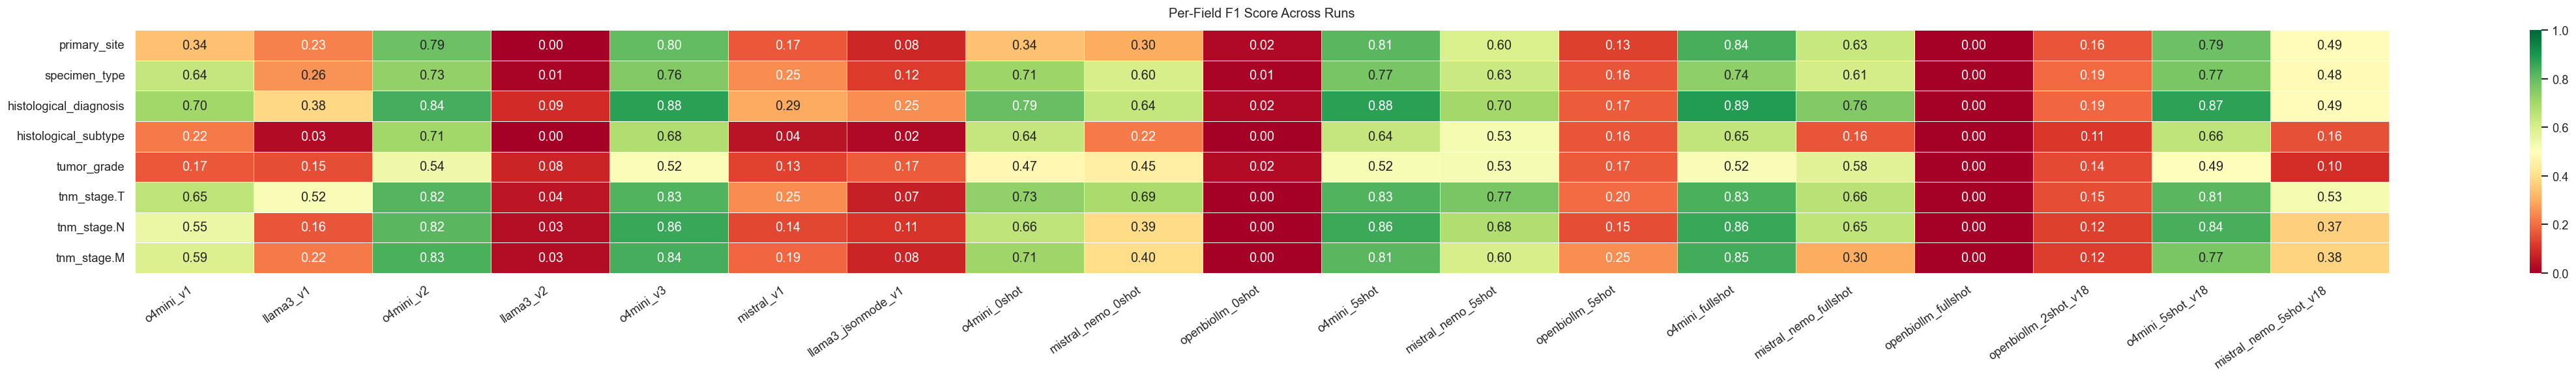

In [17]:
field_cols = ['f1_' + f.replace('.', '_') for f in ALL_FIELDS]
run_labels = (
    master_df['file']
    .apply(lambda f: f.replace('eval_results_', '').replace('.jsonl', ''))
)

heatmap_data = (
    master_df[field_cols]
    .set_axis(run_labels)
    .T
    .astype(float)
)
heatmap_data.index = ALL_FIELDS

fig, ax = plt.subplots(figsize=(max(8, len(master_df) * 2), 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
)
ax.set_title('Per-Field F1 Score Across Runs', pad=12)
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 4b. Per-Field Semantic Similarity Heatmap

Rows = semantic-scored fields, columns = runs. Mean cosine similarity (0–1) between predicted and ground-truth text embeddings.

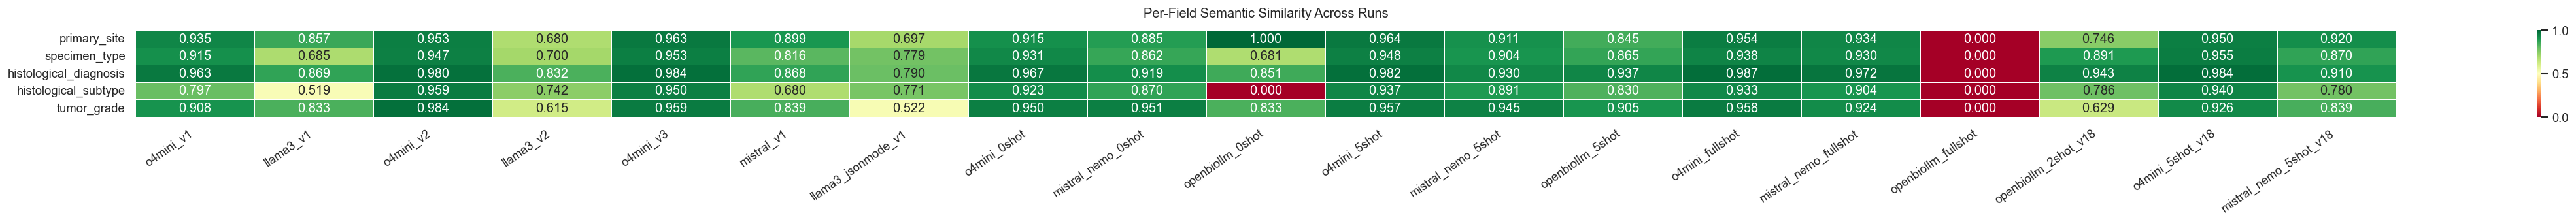

In [18]:
sim_cols = ['sim_' + f.replace('.', '_') for f in SEMANTIC_FIELDS]
run_labels = (
    master_df['file']
    .apply(lambda f: f.replace('eval_results_', '').replace('.jsonl', ''))
)

sim_heatmap = (
    master_df[sim_cols]
    .set_axis(run_labels)
    .T
    .astype(float)
)
sim_heatmap.index = SEMANTIC_FIELDS

fig, ax = plt.subplots(figsize=(max(8, len(master_df) * 2), 3))
sns.heatmap(
    sim_heatmap,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
)
ax.set_title('Per-Field Semantic Similarity Across Runs', pad=12)
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 5. Pass/Fail Summary & Trend Charts

Pass criteria: weighted F1 ≥ 0.85 **and** mean similarity ≥ 0.85 **and** combined_score ≥ 0.80.
Trend lines show metric evolution per model across chronological runs.

In [19]:
F1_THRESHOLD       = 0.85
SIM_THRESHOLD      = 0.85
COMBINED_THRESHOLD = 0.80

run_labels = (
    master_df['file']
    .apply(lambda f: f.replace('eval_results_', '').replace('.jsonl', ''))
)

passfail_df = master_df[['model', 'prompt_version', 'weighted_F1', 'mean_similarity', 'combined_score']].copy()
passfail_df.index = run_labels
passfail_df['passed'] = (
    (passfail_df['weighted_F1']    >= F1_THRESHOLD) &
    (passfail_df['mean_similarity'] >= SIM_THRESHOLD) &
    (passfail_df['combined_score'].fillna(0) >= COMBINED_THRESHOLD)
).map({True: '✓ pass', False: '✗ fail'})


def _pass_style(col: pd.Series) -> list[str]:
    return [
        'color: green; font-weight: bold' if v == '✓ pass'
        else ('color: red; font-weight: bold' if v == '✗ fail' else '')
        for v in col
    ]


display(
    passfail_df.style
    .background_gradient(subset=['weighted_F1'],    cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['mean_similarity'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['combined_score'],  cmap='RdYlGn', vmin=0, vmax=1)
    .apply(_pass_style, subset=['passed'])
    .format({
        'weighted_F1':    '{:.4f}',
        'mean_similarity': '{:.4f}',
        'combined_score':  '{:.4f}',
    }, na_rep='—')
    .set_caption(
        f'Pass/Fail — weighted F1 ≥ {F1_THRESHOLD} AND mean similarity ≥ {SIM_THRESHOLD} AND combined_score ≥ {COMBINED_THRESHOLD}'
    )
)

,model,prompt_version,weighted_F1,mean_similarity,combined_score,passed
file,,,,,,
o4mini_v1,openai:o4-mini,v1.3,0.4906,0.9036,0.6615,✗ fail
llama3_v1,ollama:llama3.2,v1.3,0.2578,0.7527,0.3996,✗ fail
o4mini_v2,openai:o4-mini,v1.4,0.7628,0.9645,0.8591,✗ fail
llama3_v2,ollama:llama3.2,v1.4,0.0408,0.7140,0.0947,✗ fail
o4mini_v3,openai:o4-mini,v1.5,0.7738,0.9617,0.8870,✗ fail
mistral_v1,ollama:mistral:7b,v1.5,0.1800,0.8204,0.2695,✗ fail
llama3_jsonmode_v1,ollama:llama3.2,v1.5,0.1126,0.7120,0.2115,✗ fail
o4mini_0shot,openai:o4-mini,v1.7,0.6498,0.9373,0.8026,✗ fail
mistral_nemo_0shot,ollama:mistral-nemo,v1.7,0.4773,0.8972,0.6504,✗ fail


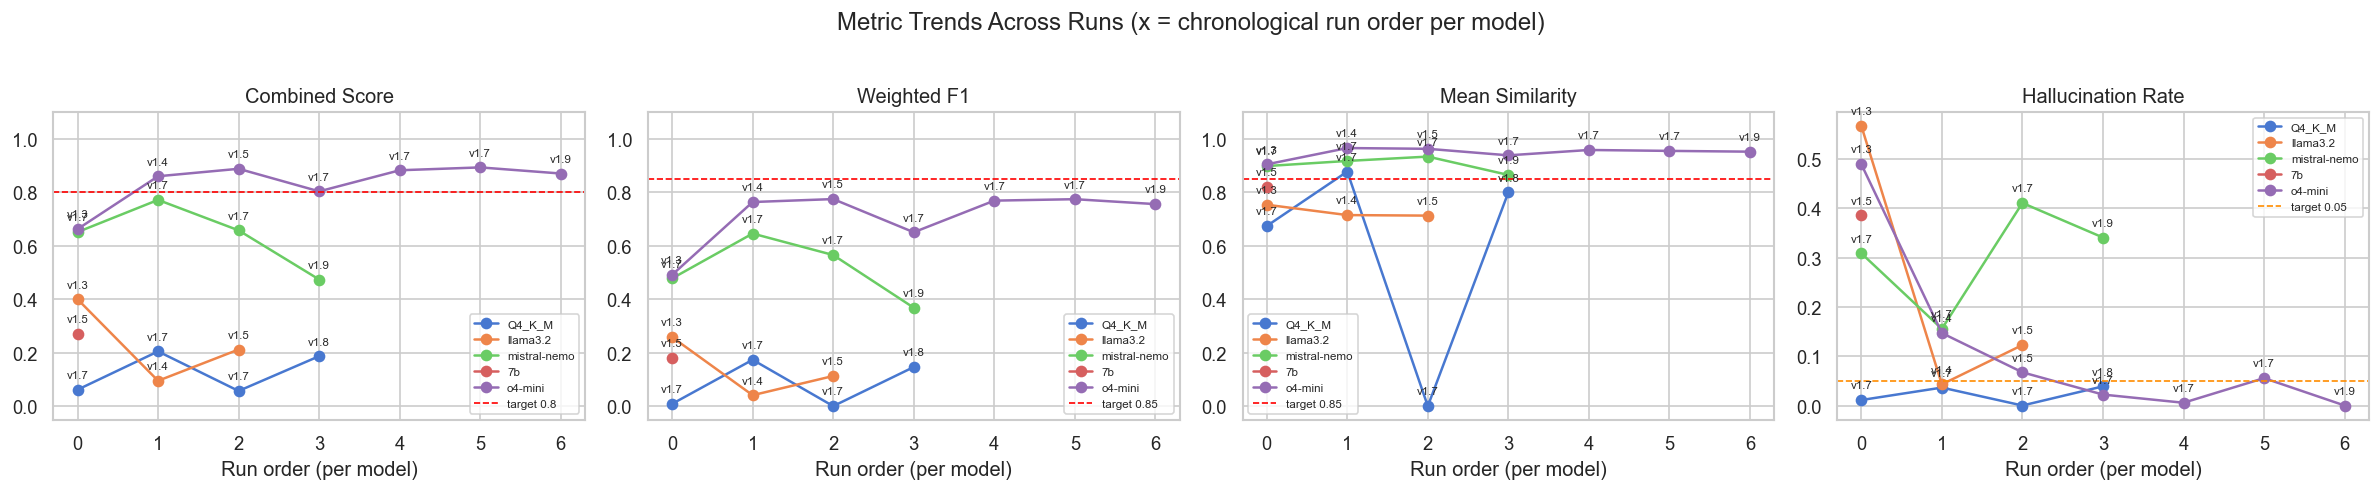

In [20]:
metrics_cfg = [
    ('combined_score',     'Combined Score',          0.80,  True),
    ('weighted_F1',        'Weighted F1',             0.85,  True),
    ('mean_similarity',    'Mean Similarity',         0.85,  True),
    ('hallucination_rate', 'Hallucination Rate',      0.05,  False),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (col, title, target, higher_better) in zip(axes, metrics_cfg):
    for model, grp in master_df.groupby('model'):
        short = model.split(':')[-1]
        grp_s = grp.sort_values('created_at').reset_index(drop=True)
        ax.plot(grp_s.index, grp_s[col], marker='o', label=short)
        for xi, row in grp_s.iterrows():
            ax.annotate(
                row['prompt_version'],
                (xi, row[col]),
                textcoords='offset points', xytext=(0, 7),
                fontsize=7, ha='center',
            )
    if target is not None:
        lc = 'red' if higher_better else 'darkorange'
        ax.axhline(target, color=lc, linestyle='--', linewidth=1,
                   label=f'target {target}')
    ax.set_title(title)
    ax.set_xlabel('Run order (per model)')
    ax.legend(fontsize=7)
    if col in ('combined_score', 'weighted_F1', 'mean_similarity'):
        ax.set_ylim(-0.05, 1.1)

plt.suptitle(
    'Metric Trends Across Runs (x = chronological run order per model)',
    y=1.02,
)
plt.tight_layout()
plt.show()